# Executive Fraud Analytics Dashboard

This dashboard provides a real-time overview of:

- Fraud activity
- Risk distribution
- Alert management
- Business impact
- Investigation workload

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
model = joblib.load(
    "../models/random_forest_fraud_detector.pkl"
)

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [3]:
df = pd.read_csv(
    "../data/processed/fraud_risk_scored.csv"
)

print(df.shape)

df.head()

(6362620, 33)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,account_tenure_months,fraud_probability,risk_score,risk_category,alert_priority,recommended_action,alert_message,review_required,investigation_required,fraud_severity
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,20,0.000000,0.00,Low,Normal,Approve Transaction,LOW RISK TRANSACTION | Risk Score: 0.0,No,No,No Risk
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,7,0.000000,0.00,Low,Normal,Approve Transaction,LOW RISK TRANSACTION | Risk Score: 0.0,No,No,No Risk
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,...,39,0.729989,73.00,High,Urgent,Require Multi-Factor Verification,HIGH RISK TRANSACTION | Risk Score: 73.0,Yes,Yes,Moderate
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,...,116,0.589770,58.98,Medium,Review,Manual Review Recommended,MEDIUM RISK TRANSACTION | Risk Score: 58.98,Yes,No,Minor
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,...,19,0.000000,0.00,Low,Normal,Approve Transaction,LOW RISK TRANSACTION | Risk Score: 0.0,No,No,No Risk


In [4]:
type(model)
df.shape

(6362620, 33)

In [5]:
print(df.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'transaction_hour', 'transaction_day', 'transaction_week', 'balance_error_org', 'balance_error_dest', 'customer_type', 'merchant_type', 'age_group', 'customer_segment', 'channel', 'device_type', 'risk_region', 'account_tenure_months', 'fraud_probability', 'risk_score', 'risk_category', 'alert_priority', 'recommended_action', 'alert_message', 'review_required', 'investigation_required', 'fraud_severity']


In [9]:
kpi_df = pd.read_csv(
    "../data/processed/executive_kpis.csv"
)

kpi_df

,KPI,Value
0,Total Transactions,6.362620e+06
1,Fraud Transactions,8.213000e+03
2,Fraud Rate (%),1.291000e-01
3,Total Transaction Amount,1.144393e+12
4,Average Transaction Amount,1.798619e+05
5,Critical Alerts,7.352000e+03
6,High Risk Transactions,7.320000e+02
7,Investigation Required,8.084000e+03
8,Review Required,8.193000e+03


In [10]:
kpis = dict(
    zip(
        kpi_df["KPI"],
        kpi_df["Value"]
    )
)

kpis

{'Total Transactions': 6362620.0,
 'Fraud Transactions': 8213.0,
 'Fraud Rate (%)': 0.1291,
 'Total Transaction Amount': 1144392944759.77,
 'Average Transaction Amount': 179861.9,
 'Critical Alerts': 7352.0,
 'High Risk Transactions': 732.0,
 'Investigation Required': 8084.0,
 'Review Required': 8193.0}

In [11]:
print("="*50)

print(
    "TOTAL TRANSACTIONS:",
    f"{int(kpis['Total Transactions']):,}"
)

print(
    "FRAUD TRANSACTIONS:",
    f"{int(kpis['Fraud Transactions']):,}"
)

print(
    "FRAUD RATE:",
    round(kpis["Fraud Rate (%)"],4),
    "%"
)

print(
    "CRITICAL ALERTS:",
    int(kpis["Critical Alerts"])
)

print(
    "INVESTIGATIONS:",
    int(kpis["Investigation Required"])
)

print("="*50)

TOTAL TRANSACTIONS: 6,362,620
FRAUD TRANSACTIONS: 8,213
FRAUD RATE: 0.1291 %
CRITICAL ALERTS: 7352
INVESTIGATIONS: 8084


In [12]:
risk_summary = pd.read_csv(
    "../data/processed/risk_summary.csv"
)

risk_summary

,risk_category,transaction_count,avg_risk_score,total_amount,sort_order,percentage
0,Low,6354427,0.440267,1.132347e+12,1,99.87
1,Medium,109,61.486789,3.141904e+07,2,0.00
2,High,732,83.269577,3.218763e+08,3,0.01
3,Critical,7352,98.549139,1.169291e+10,4,0.12


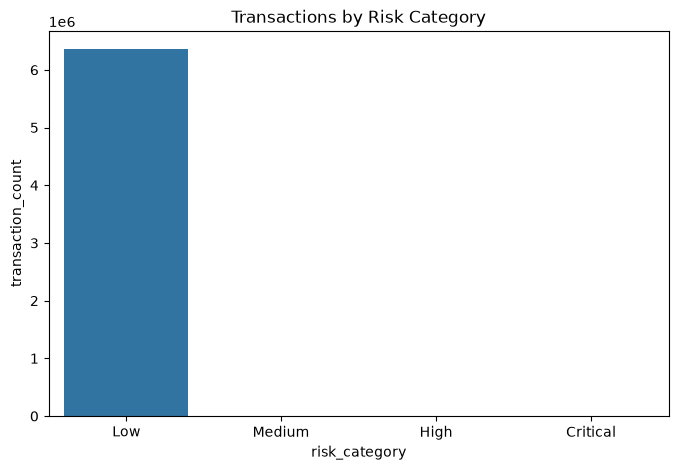

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_summary,
    x="risk_category",
    y="transaction_count"
)

plt.title("Transactions by Risk Category")

plt.show()

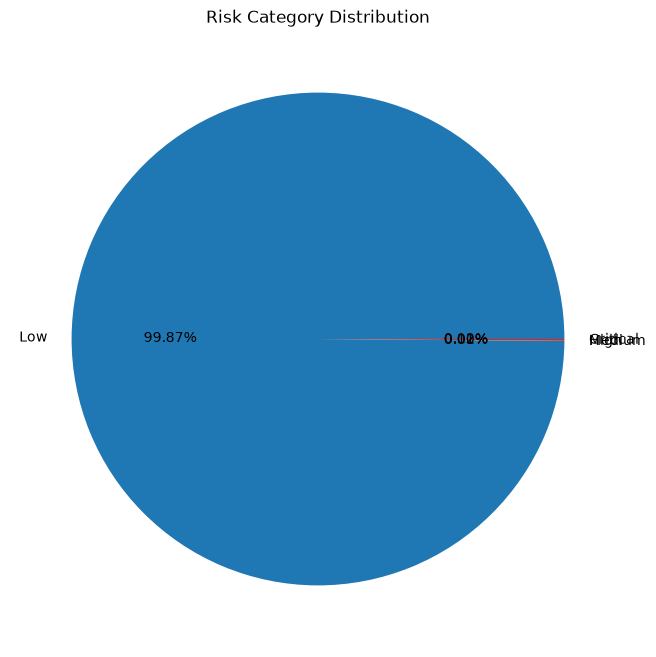

In [15]:
plt.figure(figsize=(8,8))

plt.pie(
    risk_summary["transaction_count"],
    labels=risk_summary["risk_category"],
    autopct="%1.2f%%"
)

plt.title("Risk Category Distribution")

plt.show()

In [16]:
severity_summary = pd.read_csv(
    "../data/processed/severity_summary.csv"
)

severity_summary

,fraud_severity,transaction_count,avg_risk_score,total_amount,sort_order,percentage
0,No Risk,6354427,0.440267,1.132347e+12,1,99.8712
1,Minor,33,51.755455,5.302915e+06,2,0.0005
2,Moderate,282,73.494929,1.149554e+08,3,0.0044
3,Severe,1248,90.013550,7.112112e+08,4,0.0196
4,Extreme,6630,99.158107,1.121473e+10,5,0.1042


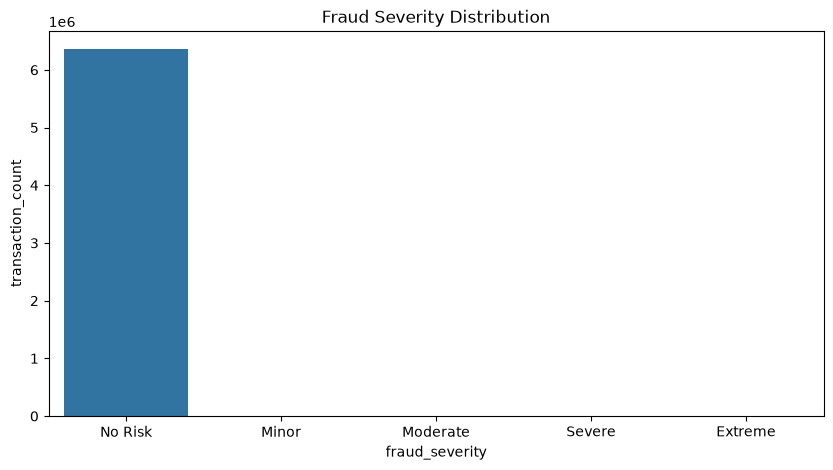

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=severity_summary,
    x="fraud_severity",
    y="transaction_count"
)

plt.title("Fraud Severity Distribution")

plt.show()

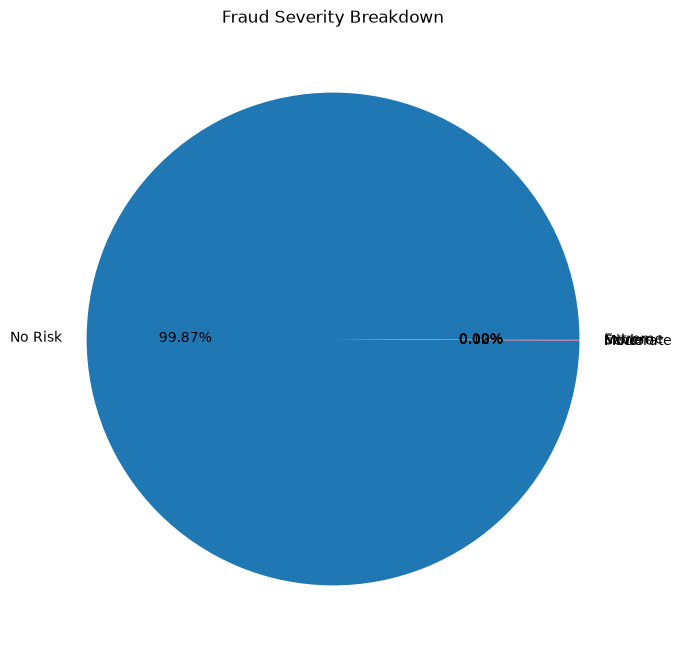

In [18]:
plt.figure(figsize=(8,8))

plt.pie(
    severity_summary["transaction_count"],
    labels=severity_summary["fraud_severity"],
    autopct="%1.2f%%"
)

plt.title("Fraud Severity Breakdown")

plt.show()

In [24]:
regional_summary = pd.read_csv(
    "../data/processed/regional_summary.csv"
)

regional_summary

,risk_region,total_transactions,fraud_transactions,avg_risk_score,total_amount,fraud_rate
0,West,1273304,1688,0.563726,2.299553e+11,0.1326
1,North,1272748,1668,0.567419,2.290910e+11,0.1311
2,Central,1272675,1664,0.562433,2.282602e+11,0.1307
3,East,1272037,1597,0.556362,2.291810e+11,0.1255
4,South,1271856,1596,0.571093,2.279055e+11,0.1255


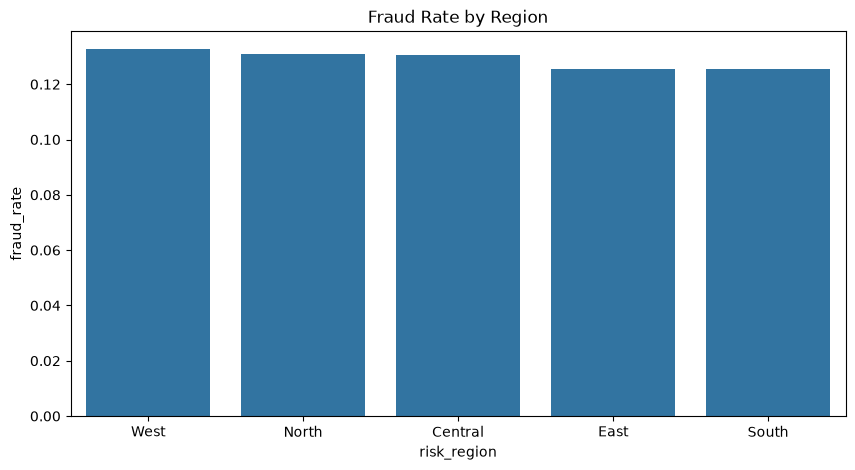

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=regional_summary,
    x="risk_region",
    y="fraud_rate"
)

plt.title("Fraud Rate by Region")

plt.show()

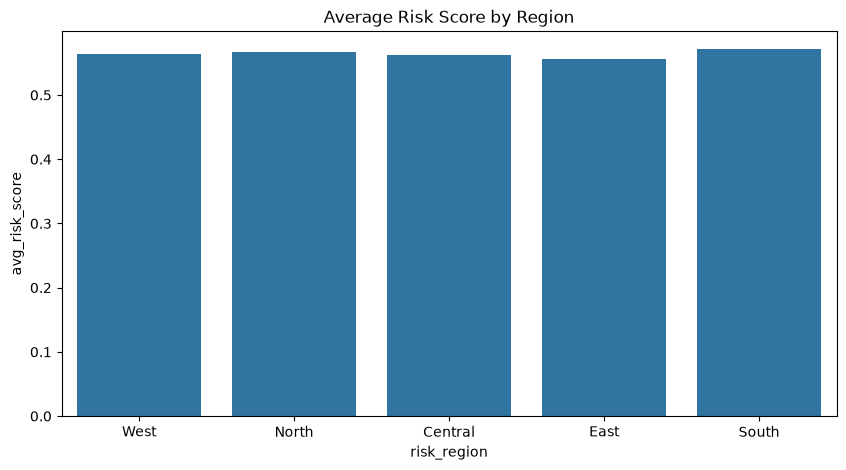

In [26]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=regional_summary,
    x="risk_region",
    y="avg_risk_score"
)

plt.title("Average Risk Score by Region")

plt.show()

In [27]:
customer_summary = pd.read_csv(
    "../data/processed/customer_summary.csv"
)

customer_summary

,customer_segment,total_transactions,fraud_transactions,avg_risk_score,avg_transaction_amount,fraud_rate
0,Retail,4453569,5760,0.571040,179854.328578,0.1293
1,Premium,1273058,1637,0.558300,179749.085845,0.1286
2,Business,635993,816,0.528175,180140.773184,0.1283


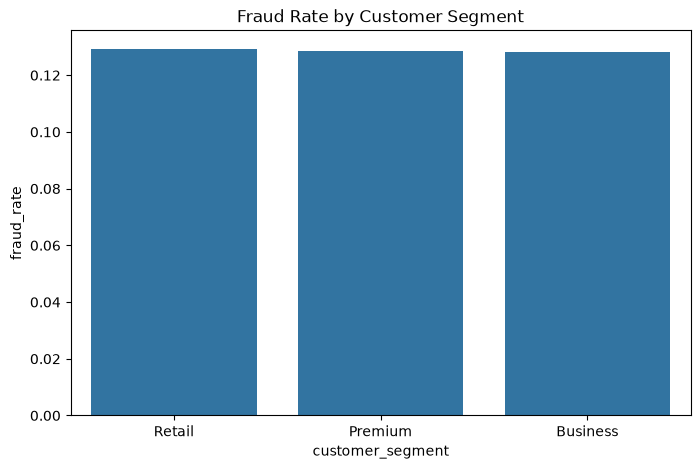

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_summary,
    x="customer_segment",
    y="fraud_rate"
)

plt.title("Fraud Rate by Customer Segment")

plt.show()

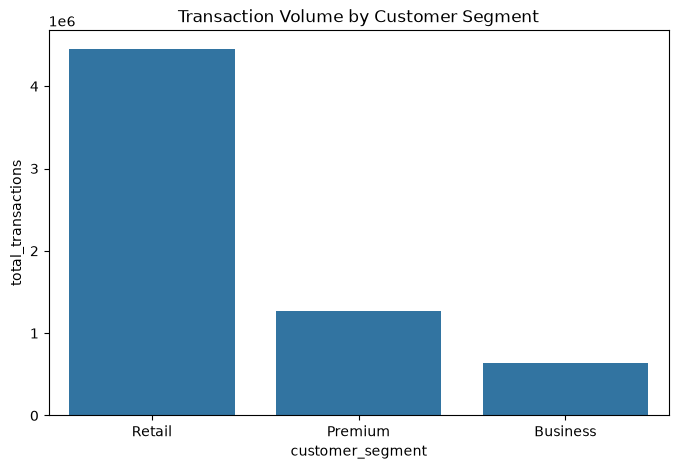

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_summary,
    x="customer_segment",
    y="total_transactions"
)

plt.title("Transaction Volume by Customer Segment")

plt.show()

In [ ]:
regional_summary.shape
customer_summary.shape

(5, 6)